# AAPL Getiri Tahmini: CNN-BiLSTM Hibrit Model

Bu notebook, Apple (AAPL) hissesinin bir sonraki islem gunundeki log getirisini tahmin etmek icin cok olcekli bir 1B-CNN ile iki katmanli cift yonlu LSTM mimarisini birlestirir.

Calisma akisi; veri hazirlama, 35 teknik ozelligin olusturulmasi, zaman bazli egitim-test ayrimi, sequence uretimi, hibrit modelin egitilmesi ve test performansinin RMSE/MAE metrikleriyle degerlendirilmesi adimlarindan olusur.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, LSTM, Bidirectional, Conv1D,
    Dropout, BatchNormalization, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

np.random.seed(42)
tf.random.set_seed(42)
plt.style.use("seaborn-v0_8-whitegrid")


C:\Users\semih\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 1. Kutuphaneler ve Deney Ayarlari

Modelin yeniden uretilebilir olmasi icin rastgelelik tohumlari sabitlenir. Kullanilan temel bilesenler:

- `pandas` ve `numpy`: veri hazirlama ve sayisal islemler
- `scikit-learn`: standardizasyon ve hata metrikleri
- `TensorFlow/Keras`: CNN-BiLSTM modelinin kurulmasi ve egitilmesi
- `matplotlib`: egitim egrileri ve tahmin hatalarinin gorsellestirilmesi


In [2]:
data = pd.read_csv("data/filled_aapl.csv", parse_dates=["Date"], index_col="Date")
data.index = pd.to_datetime(data.index, utc=True)
data = data.sort_index()

print(f"Veri boyutu: {data.shape}")
print(f"Tarih araligi: {data.index.min().date()} - {data.index.max().date()}")
display(data.head())


Veri boyutu: (11686, 7)
Tarih araligi: 1980-12-12 - 2025-09-26


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1980-12-12 05:00:00+00:00,0.098485,0.098913,0.098485,0.098485,469033600.0,0.0,0.0
1980-12-15 05:00:00+00:00,0.093775,0.093775,0.093347,0.093347,175884800.0,0.0,0.0
1980-12-16 05:00:00+00:00,0.086924,0.086924,0.086495,0.086495,105728000.0,0.0,0.0
1980-12-17 05:00:00+00:00,0.088636,0.089064,0.088636,0.088636,86441600.0,0.0,0.0
1980-12-18 05:00:00+00:00,0.091206,0.091634,0.091206,0.091206,73449600.0,0.0,0.0


## 2. Veri Yukleme ve Ozellik Muhendisligi

Ham AAPL verisi tarih sirasina gore duzenlenir. Ardindan yalnizca tahmin aninda bilinen bugunku ve gecmis gozlemlerden teknik gostergeler uretilir.

Hedef degisken su sekilde tanimlanir:

```text
target_t = log(Close[t+1] / Close[t])
```

Bu tanim, modelin mevcut gunun bilgileriyle bir sonraki islem gununun log getirisini tahmin etmesini saglar.


In [3]:
df = data.copy()

df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df["hl_range"] = np.log(df["High"] / df["Low"])
df["oc_return"] = np.log(df["Close"] / df["Open"])
df["co_return"] = np.log(df["Open"] / df["Close"].shift(1))
df["volume_change"] = np.log(df["Volume"].replace(0, np.nan) / df["Volume"].replace(0, np.nan).shift(1))
df["dollar_volume"] = np.log((df["Close"] * df["Volume"]).replace(0, np.nan))

for lag in range(1, 16):
    df[f"log_return_lag{lag}"] = df["log_return"].shift(lag)

for window in [5, 10, 20, 60]:
    df[f"volatility_{window}"] = df["log_return"].rolling(window).std()
    df[f"momentum_{window}"] = df["log_return"].rolling(window).sum()
    df[f"mean_return_{window}"] = df["log_return"].rolling(window).mean()

delta = df["Close"].diff()
gain = delta.where(delta > 0, 0).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
df["RSI_14"] = 100 - (100 / (1 + gain / loss))

for window in [20, 60]:
    df[f"close_to_ma_{window}"] = np.log(df["Close"] / df["Close"].rolling(window).mean())

df["target"] = df["log_return"].shift(-1)
df = df.replace([np.inf, -np.inf], np.nan).dropna()

feature_cols = [
    col for col in df.columns
    if col not in data.columns and col not in ["log_return", "target"]
]

X = df[feature_cols]
y = df["target"]

assert len(feature_cols) == 35, f"Beklenen 35 ozellik yerine {len(feature_cols)} ozellik bulundu."
print(f"Veri boyutu: {df.shape}")
print(f"X shape: {X.shape}")
print(f"Ozellik sayisi: {len(feature_cols)}")


Veri boyutu: (10840, 44)
X shape: (10840, 35)
Ozellik sayisi: 35


## 3. Veri Setinin Hazirlanmasi

Ozellik matrisi `X`, hedef vektoru ise `y` olarak ayrilir. Modelde kullanilan ozellikler derin ogrenme modelleri notebookundaki tanimlarla aynidir ve toplam 35 teknik ozellik icerir.

Eksik ve sonsuz degerler temizlendikten sonra ozellik sayisi kontrol edilir. Bu kontrol, modelin eksik veya farkli sayida ozellikle egitilmesini onler.


In [4]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx - 1], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx - 1], y.iloc[split_idx:]

print(f"Egitim seti: {X_train.shape[0]} gozlem ({X_train.index.min().date()} - {X_train.index.max().date()})")
print(f"Test seti: {X_test.shape[0]} gozlem ({X_test.index.min().date()} - {X_test.index.max().date()})")
print(f"Test orani: {X_test.shape[0] / len(X) * 100:.1f}%")


Egitim seti: 8671 gozlem (1981-03-06 - 2016-10-05)
Test seti: 2168 gozlem (2016-10-07 - 2025-09-25)
Test orani: 20.0%


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Zaman Bazli Egitim-Test Ayrimi ve Standardizasyon

Zaman serilerinde gelecek bilgisi gecmise tasinmamalidir. Bu nedenle verinin ilk %80'i egitim, son %20'si test icin ayrilir.

`StandardScaler` yalnizca egitim verisi uzerinde fit edilir; test verisi ayni donusumle olceklendirilir. Boylece test doneminin dagilimi egitim asamasinda kullanilmaz.


In [7]:
def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(time_steps, len(X)):
        Xs.append(X[i - time_steps:i])
        ys.append(y[i])
    return np.asarray(Xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)

SEQUENCE_LENGTH = 60

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, SEQUENCE_LENGTH)
X_test_context = np.concatenate([X_train_scaled[-SEQUENCE_LENGTH:], X_test_scaled])
y_test_context = np.concatenate([y_train.values[-SEQUENCE_LENGTH:], y_test.values])
X_test_seq, y_test_seq = create_sequences(X_test_context, y_test_context, SEQUENCE_LENGTH)

validation_size = int(len(X_train_seq) * 0.2)
X_fit_seq, X_val_seq = X_train_seq[:-validation_size], X_train_seq[-validation_size:]
y_fit_seq, y_val_seq = y_train_seq[:-validation_size], y_train_seq[-validation_size:]

print(f"Sequence uzunlugu: {SEQUENCE_LENGTH}")
print(f"X_fit_seq shape: {X_fit_seq.shape}")
print(f"X_val_seq shape: {X_val_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}")


Sequence uzunlugu: 60
X_fit_seq shape: (6889, 60, 35)
X_val_seq shape: (1722, 60, 35)
X_test_seq shape: (2168, 60, 35)


## 5. Zaman Pencerelerinin Olusturulmasi

CNN-BiLSTM modeli, tek bir satir yerine gecmis 60 islem gununden olusan zaman pencereleriyle calisir.

- Girdi: `(ornek sayisi, 60 zaman adimi, 35 ozellik)`
- Hedef: Pencerenin hemen sonrasindaki gunun log getirisi

Test doneminin ilk tahmini icin egitim setinin son 60 gozlemi baglam olarak eklenir. Bu islem test hedeflerini egitim verisiyle karistirmaz; yalnizca gerekli gecmis zaman baglamini saglar.


In [8]:
def build_cnn_bilstm(seq_length, n_features):
    inputs = Input(shape=(seq_length, n_features), name="input")

    conv_2 = Conv1D(32, 2, padding="same", activation="relu", kernel_regularizer=l2(0.0005))(inputs)
    conv_3 = Conv1D(32, 3, padding="same", activation="relu", kernel_regularizer=l2(0.0005))(inputs)
    conv_5 = Conv1D(16, 5, padding="same", activation="relu", kernel_regularizer=l2(0.0005))(inputs)
    x = Concatenate(name="multi_scale_cnn")([conv_2, conv_3, conv_5])
    x = BatchNormalization()(x)
    x = Dropout(0.15)(x)

    x = Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.0005)))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.20)(x)
    x = Bidirectional(LSTM(32, return_sequences=False, kernel_regularizer=l2(0.0005)))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.20)(x)

    x = Dense(64, activation="relu", kernel_regularizer=l2(0.0005))(x)
    x = Dropout(0.15)(x)
    x = Dense(32, activation="relu", kernel_regularizer=l2(0.0005))(x)
    outputs = Dense(1, activation="linear", name="output")(x)

    return Model(inputs, outputs, name="CNN_BiLSTM_Hybrid")

model = build_cnn_bilstm(SEQUENCE_LENGTH, len(feature_cols))
model.compile(
    optimizer=Adam(learning_rate=0.0005, clipnorm=1.0),
    loss="mse",
    metrics=["mae"],
)

print(f"Toplam parametre: {model.count_params():,}")
model.summary()


Toplam parametre: 131,297


Model: "CNN_BiLSTM_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 60, 35)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 60, 32)    │      2,272 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 60, 32)    │      3,392 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 60, 16)    │      2,816 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_scale_cnn     │ (None, 60, 80)    │          0 │ conv1d[0][0],     │
│ (Concatenate)       │                   │            │ conv1d_1[0][0],   │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 60, 80)    │        320 │ multi_scale_cnn[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 60, 80)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 60, 128)   │     74,240 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 128)   │        512 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 60, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     41,216 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ bidirectional_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 131,297 (512.88 KB)

 Trainable params: 130,753 (510.75 KB)

 Non-trainable params: 544 (2.12 KB)

## 6. CNN-BiLSTM Hibrit Model Mimarisi

Model iki tamamlayici bileseni birlestirir:

1. Cok olcekli CNN: Kernel boyutlari 2, 3 ve 5 olan paralel `Conv1D` katmanlari farkli uzunluktaki yerel zaman desenlerini cikarir.
2. Cift yonlu LSTM: CNN ciktilarindaki zaman bagimliliklarini ileri ve geri yonde isler.

| Bilesen | Yapi | Amac |
|---|---:|---|
| Cok olcekli CNN | 32, 32 ve 16 filtre; kernel 2, 3, 5 | Yerel desenleri yakalamak |
| BiLSTM-1 | 64 hucre | Zengin zaman temsili olusturmak |
| BiLSTM-2 | 32 hucre | Temsili sikistirmak ve ozetlemek |
| Dense katmanlari | 64 ve 32 noron | Regresyon oncesi donusum |
| Cikis | 1 noron, linear | Bir sonraki gunun log getirisi |

Batch normalization, dropout ve L2 regularization asiri ogrenmeyi azaltmak icin kullanilir.


In [9]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=8, min_lr=1e-7, verbose=1),
]

history = model.fit(
    X_fit_seq,
    y_fit_seq,
    epochs=150,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=callbacks,
    verbose=1,
)

print(f"\nEgitim tamamlandi. Toplam epoch: {len(history.history['loss'])}")


Epoch 1/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - loss: 0.4742 - mae: 0.2696 - val_loss: 0.3389 - val_mae: 0.0650 - learning_rate: 5.0000e-04
Epoch 2/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 0.3505 - mae: 0.1368 - val_loss: 0.3151 - val_mae: 0.0731 - learning_rate: 5.0000e-04
Epoch 3/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - loss: 0.3089 - mae: 0.1000 - val_loss: 0.2827 - val_mae: 0.0562 - learning_rate: 5.0000e-04
Epoch 4/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 0.2730 - mae: 0.0795 - val_loss: 0.2495 - val_mae: 0.0377 - learning_rate: 5.0000e-04
Epoch 5/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 0.2390 - mae: 0.0644 - val_loss: 0.2188 - val_mae: 0.0316 - learning_rate: 5.0000e-04
Epoch 6/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - loss: 0.2075 - mae: 0.0525 - val_loss: 0.1901 - val_mae: 0.0287 - learning_rate: 5.0000e-04
Epoch 7/150
216/216 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - loss: 0.1791 - mae: 0.0451 - val_loss: 0.1636 - v

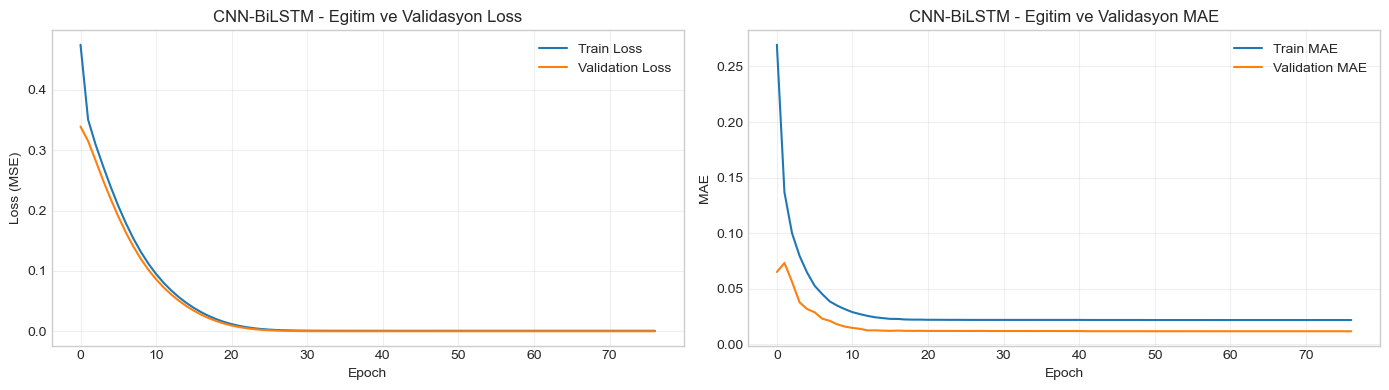

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('CNN-BiLSTM - Egitim ve Validasyon Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('CNN-BiLSTM - Egitim ve Validasyon MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Modelin Egitilmesi

Egitim sirasinda kronolojik bir dogrulama kumesi kullanilir. En iyi dogrulama kaybindaki agirliklari korumak icin `EarlyStopping`, dogrulama kaybi iyilesmediginde ogrenme oranini azaltmak icin `ReduceLROnPlateau` uygulanir.

Kayip fonksiyonu ortalama karesel hata (MSE), temel izleme metrigi ise MAE'dir. Nihai model secimi test kumesindeki RMSE degerine gore yapilir.


In [11]:
def evaluate_model(y_true, y_pred, model_name):
    y_true_arr = y_true if isinstance(y_true, np.ndarray) else y_true.values
    
    mse = mean_squared_error(y_true_arr, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_arr, y_pred)
    
    print(f"\n{model_name} - Test Performansi")
    print("-" * 50)
    print(f"MSE:  {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE:  {mae:.6f}")
    
    # Gorsellestirme
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].scatter(y_true_arr, y_pred, alpha=0.3, s=10)
    min_val, max_val = y_true_arr.min(), y_true_arr.max()
    axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
    axes[0].set_xlabel("Gercek Deger")
    axes[0].set_ylabel("Tahmin")
    axes[0].set_title(f"{model_name}\nGercek vs Tahmin")
    axes[0].grid(alpha=0.3)
    
    n_show = min(200, len(y_true_arr))
    axes[1].plot(range(n_show), y_true_arr[:n_show], label="Gercek", alpha=0.7)
    axes[1].plot(range(n_show), y_pred[:n_show], label="Tahmin", alpha=0.7)
    axes[1].set_xlabel("Gozlem")
    axes[1].set_ylabel("Log Getiri")
    axes[1].set_title(f"{model_name}\nZaman Serisi (Ilk {n_show})")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    errors = y_true_arr - y_pred
    axes[2].hist(errors, bins=50, edgecolor="white", alpha=0.7)
    axes[2].axvline(0, color="red", linestyle="--", linewidth=2)
    axes[2].axvline(np.mean(errors), color="blue", linestyle="-", linewidth=2, 
                    label=f"Ort: {np.mean(errors):.5f}")
    axes[2].set_xlabel("Hata")
    axes[2].set_ylabel("Frekans")
    axes[2].set_title(f"{model_name}\nHata Dagilimi")
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {"MSE": mse, "RMSE": rmse, "MAE": mae}


CNN-BiLSTM Hibrit - Test Performansi
--------------------------------------------------
MSE:  0.000332
RMSE: 0.018225
MAE:  0.012307


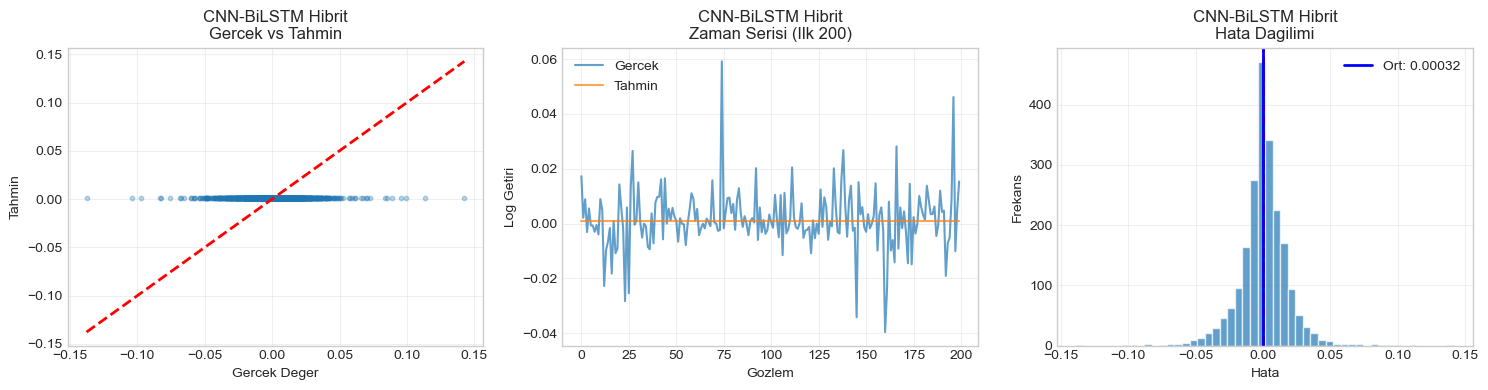

In [12]:
y_pred = model.predict(X_test_seq, verbose=0).ravel()
results = evaluate_model(y_test_seq, y_pred, "CNN-BiLSTM Hibrit")

## 8. Tahmin ve Test Performansi

Egitim tamamlandiktan sonra model test sequence'leri uzerinde tahmin uretir.

- MSE: Hatalarin karelerinin ortalamasi
- RMSE: MSE'nin karekoku; dusuk olmasi tercih edilir
- MAE: Mutlak hatalarin ortalamasi

Gercek ve tahmin degerleri, ilk test gozlemlerinin zaman serisi ve hata dagilimi birlikte gorsellestirilir.



## 9. Egitilmis Modelin Kaydedilmesi

Egitilmis model, daha sonra yeniden yuklenip tahmin uretilebilmesi icin Keras formatinda kaydedilir:

```text
saved_models/cnn_bilstm_hybrid_model.keras
``` 



In [13]:
os.makedirs("saved_models", exist_ok=True)
model.save("saved_models/cnn_bilstm_hybrid_model.keras")
print("Model kaydedildi: saved_models/cnn_bilstm_hybrid_model.keras")

Model kaydedildi: saved_models/cnn_bilstm_hybrid_model.keras
